### Carga, Transformación y Limpieza

In [1]:
# Carga de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Se establecen las rutas de trabajo
BASE_DIR = Path().resolve()
PROJECT_DIR = BASE_DIR.parent
DATA_RAW = PROJECT_DIR / 'data' / 'raw'
DATA_PROCESSED = PROJECT_DIR / 'data' / 'processed'
DATA_PROCESSED.mkdir(parents=True,exist_ok=True)

In [3]:
# Carga de archivo 
file_path = DATA_RAW / 'sp500.csv'
df = pd.read_csv(file_path)
display(df.head())
print(df.info())

,Price,Close,High,Low,Open,Volume
0,Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
1,Date,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,1132.989990234375,1133.8699951171875,1116.56005859375,1116.56005859375,3991400000
3,2010-01-05,1136.52001953125,1136.6300048828125,1129.6600341796875,1132.6600341796875,2491020000
4,2010-01-06,1137.1400146484375,1139.18994140625,1133.949951171875,1135.7099609375,4972660000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3775 entries, 0 to 3774
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   3775 non-null   object
 1   Close   3774 non-null   object
 2   High    3774 non-null   object
 3   Low     3774 non-null   object
 4   Open    3774 non-null   object
 5   Volume  3774 non-null   object
dtypes: object(6)
memory usage: 177.1+ KB
None


In [4]:
# Transformación general del dataframe
# Ajuste de las dos primeras filas del dataframe
df = df.iloc[2:,:]
# Renombración de la primer columna
df = df.rename(columns={'Price':'Date'})
# Establecemos la columna de fecha como índice
df = df.set_index('Date')
# Ordenamos de forma ascendente las fechas establecidas como índice
df = df.sort_index()
# Seleccionamos la columna con la que se trabajaremos, en este caso será 'Close'
# La columna 'Close' contiene los valores para el cierre del día durante los correspondientes días
df = df[['Close']]
# Convertimos los datos de 'Closer a tipo float'
df['Close'] = df['Close'].astype(float)
# Evaluamos la calidad de los datos, ya sean duplicados o valores nulos
print('Missing values:\n',df.isna().sum())
print('Duplicated values:\n',df.index.duplicated().sum())
# Dado que no hay valores inconsistentes, continuamos con sin realizar algún procedimiento adicional
# Visualizamos de manera rápida el dataframe
df.head()

Missing values:
 Close    0
dtype: int64
Duplicated values:
 0


,Close
Date,
2010-01-04,1132.989990
2010-01-05,1136.520020
2010-01-06,1137.140015
2010-01-07,1141.689941
2010-01-08,1144.979980


### Log-Return

A continuación se hace uso de la ecuación **Log-Return** para obtener la primer feature
\begin{equation}
r_t = ln\left(\frac{P_t}{P_{t_1}}\right)
\end{equation}

In [5]:
# Aplicamos la fórmula Log-Return
df['Log_Return'] = np.log(df['Close']/df['Close'].shift(1))
# Al aplicar la fórmula el primer valor de Log_Return nos devolverá NAN, por lo que, eliminamos los NAN
df = df.dropna()
# Evaluamos que los cálculos esten correctos para la columna calculada
df['Log_Return'].describe()
# Visualizamos de manera rápida lo obtenido
#df.head()

count    3772.000000
mean        0.000438
std         0.010890
min        -0.127652
25%        -0.003810
50%         0.000681
75%         0.005675
max         0.089683
Name: Log_Return, dtype: float64

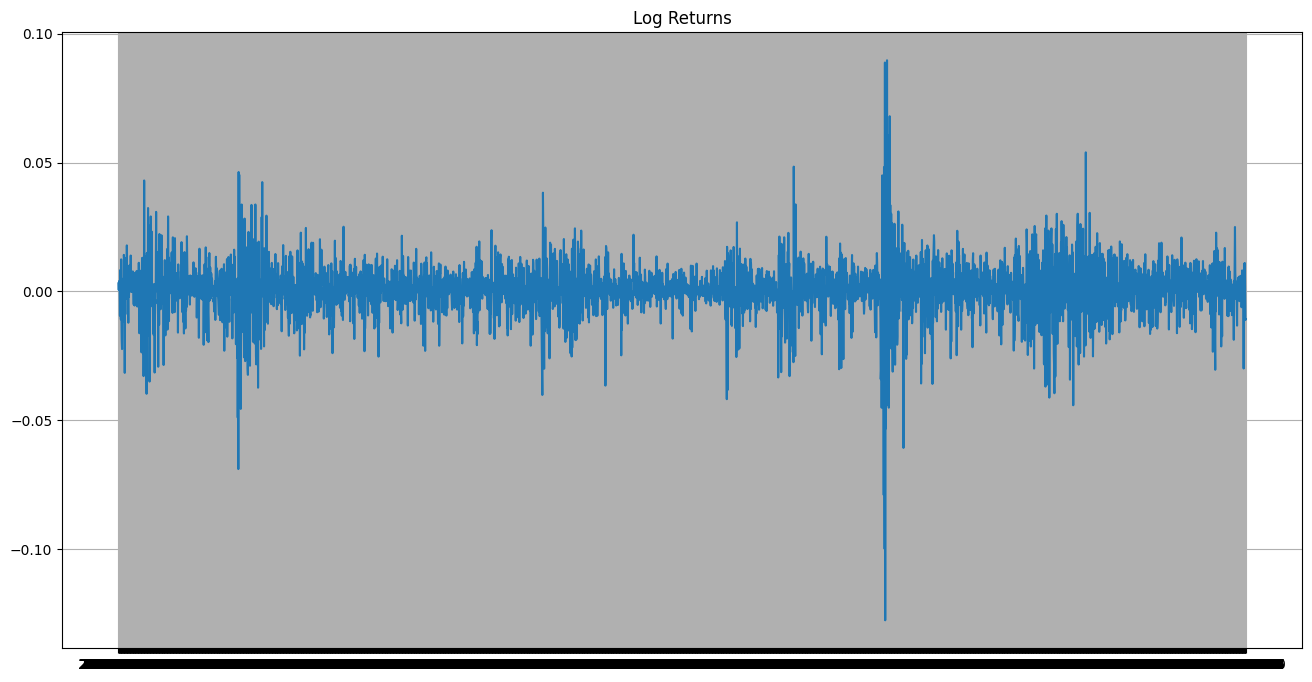

In [6]:
# Visualizamos los datos a través de un gráfico de lineas
plt.figure(figsize=(16,8))
plt.plot(df['Log_Return'])
plt.title('Log Returns')
plt.grid()
plt.show()

### Volatilidad 

A continuación se cálculará la volatilidad de nuestros datos, esto se define como la desviación estandar de Log_Return:
\begin{equation}
Volatilidad = \sigma(Log\_Return)
\end{equation}
Se implementará una ventana de 20 días.

In [7]:
# Establecemos los criterios para el cálculo de nuestra desviación estandar dentro de un rango determinado y cálculamos
window = 20
df['Volatility'] = df['Log_Return'].rolling(window=window).std()
# El uso de la ventana de 20 días nos devuelve valores NAN en multiples entradas de nuestros datos, por lo que limpiamos
df = df.dropna()
# Visualizamos de manera rápida lo obtenido
#df.head()

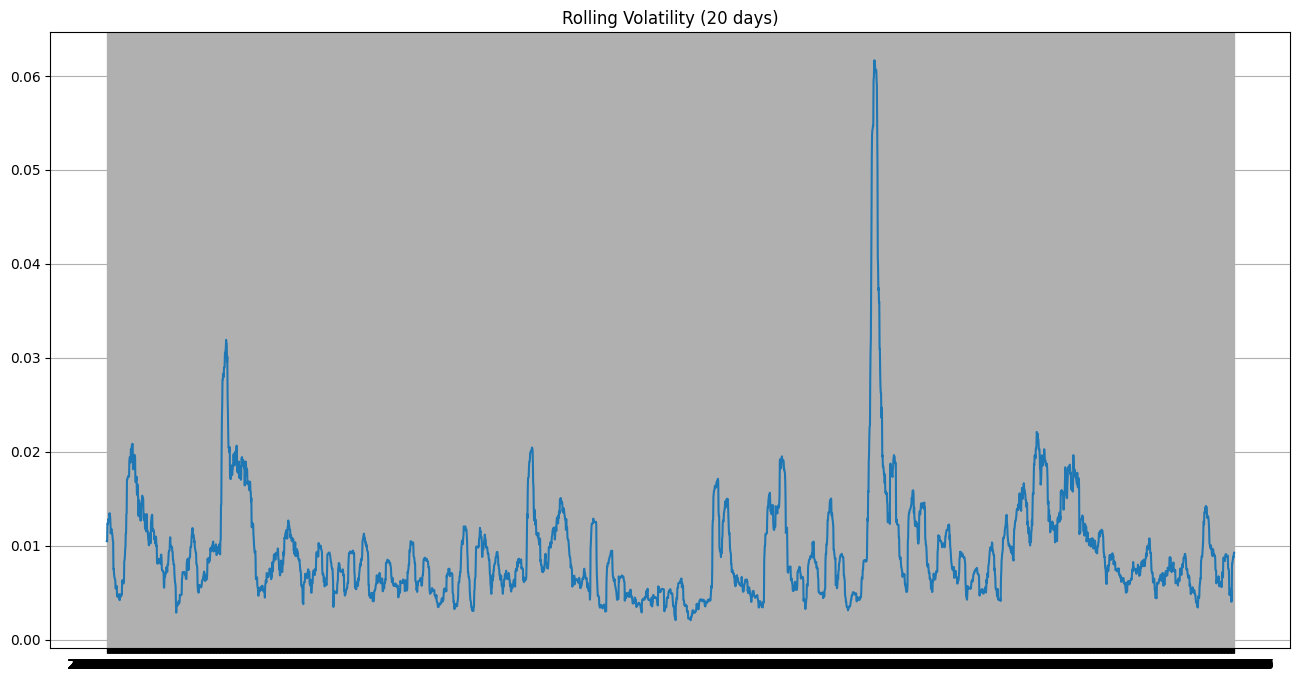

In [8]:
# Visualizamos los datos a través de un gráfico de lineas
plt.figure(figsize=(16,8))
plt.plot(df['Volatility'])
plt.title('Rolling Volatility (20 days)')
plt.grid()
plt.show()

### Eventos Extremos

Aquí se define una opción robusta para el cálculo de eventos extremos usando el percentil número 5 con una valor de $0.05$.

In [9]:
# Cálculo del percentil 5 con valor de 0.05
Threshold = df['Log_Return'].quantile(0.05)
print('Threshold:',Threshold)

Threshold: -0.016602162464914735


In [10]:
# Cálculo de valor de Evento Extremo, se usa eventos binarios
df['Extreme_Event'] = (df['Log_Return']<Threshold).astype(int)
# Evaluamos la cantidad de puntos de eventos extremos encontrados
print("Extreme events:", df["Extreme_Event"].sum())
print("Percentage:", df["Extreme_Event"].mean())
# Visualizamos de manera rápida lo obtenido
#df.head()

Extreme events: 188
Percentage: 0.05009325872635225


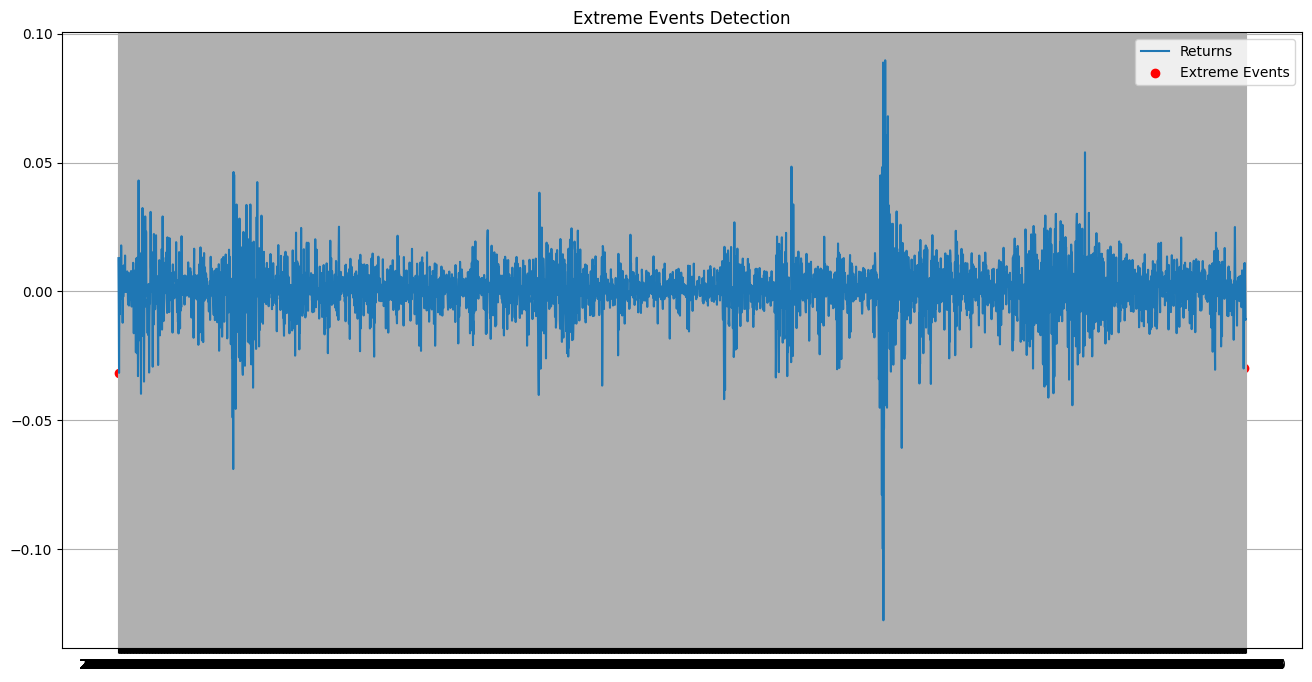

In [11]:
# Visualizamos los datos a través de un gráfico de lineas
plt.figure(figsize=(16,8))
plt.plot(df['Log_Return'],label='Returns')
plt.scatter(df.index[df['Extreme_Event']==1],
            df['Log_Return'][df['Extreme_Event']==1],
            color='red',label='Extreme Events')
plt.legend()
plt.title('Extreme Events Detection')
plt.grid()
plt.show()

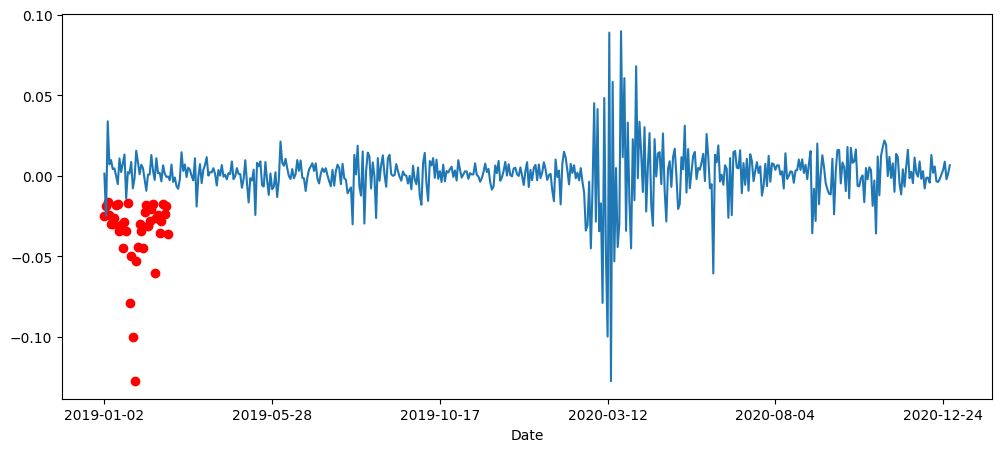

In [12]:
# Visualizamos donde se encuentran la mayoria de eventos extremos
df["Log_Return"].loc["2019":"2021"].plot(figsize=(12,5))
plt.scatter(
    df.loc["2019":"2021"].index[df.loc["2019":"2021"]["Extreme_Event"] == 1],
    df.loc["2019":"2021"]["Log_Return"][df.loc["2019":"2021"]["Extreme_Event"] == 1],
    color='red'
)

plt.show()

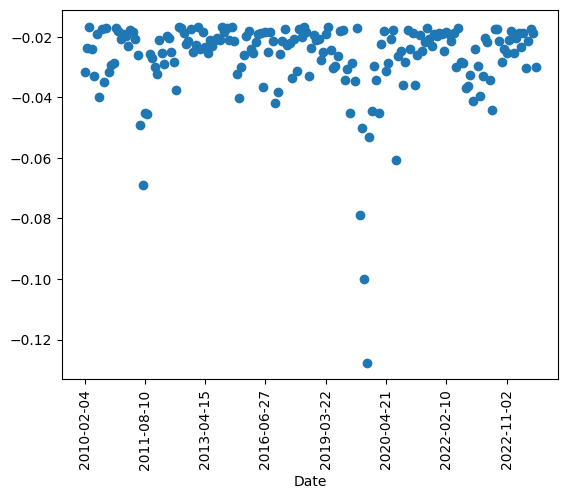

In [13]:
# Visualizamos únicamente los eventos extremos para tener mayor claridad
df[df["Extreme_Event"] == 1]["Log_Return"].plot(style='o')
plt.xticks(rotation=90)
plt.show()

### Guardado de Resultados

In [14]:
output_path = DATA_PROCESSED / 'sp500_features.csv'
df.to_csv(output_path)
print('File saved in:''output_path')

File saved in:output_path
